   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

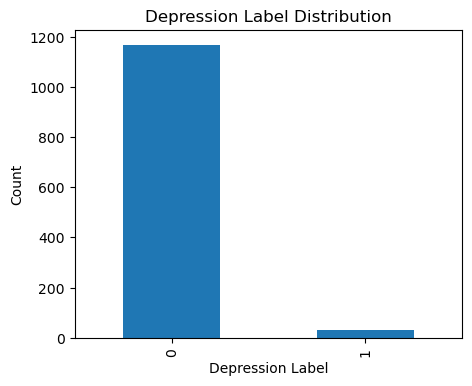


Class Distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64

Encoded Features:
   age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0   14                       7.9          7.4                       2.9   
1   19                       1.9          8.0                       2.9   
2   17                       1.3          7.6                       0.5   
3   15                       7.4          6.9                       1.6   
4   15                       4.7          4.9                       3.0   

   academic_performance  physical_activity  stress_level  anxiety_level  \
0                  3.01                1.5             2              2   
1                  3.22                0.8             8              1   
2                  3.92                0.0             2              4   
3                  3.48                0.8             1              7   
4                  2.37                1.4             3              5

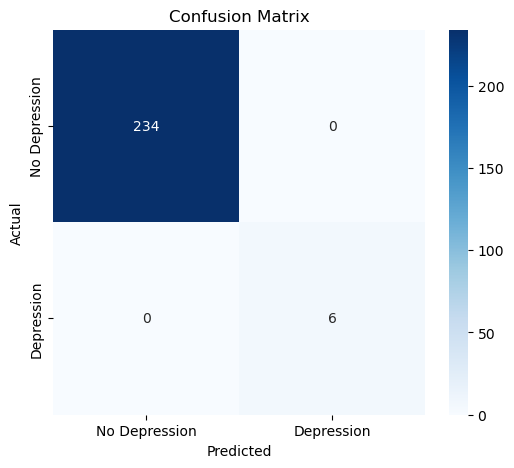

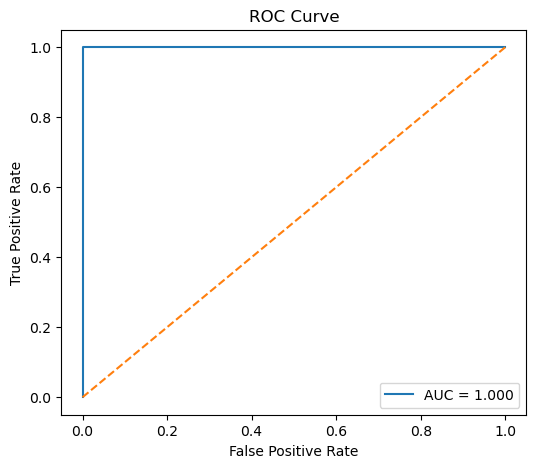


Feature Importance:

                            Feature  Importance
6                      stress_level    0.465517
2                       sleep_hours    0.313741
7                     anxiety_level    0.164609
1          daily_social_media_hours    0.056133
0                               age    0.000000
3          screen_time_before_sleep    0.000000
4              academic_performance    0.000000
5                 physical_activity    0.000000
8                   addiction_level    0.000000
9                       gender_male    0.000000
10         platform_usage_Instagram    0.000000
11            platform_usage_TikTok    0.000000
12     social_interaction_level_low    0.000000
13  social_interaction_level_medium    0.000000


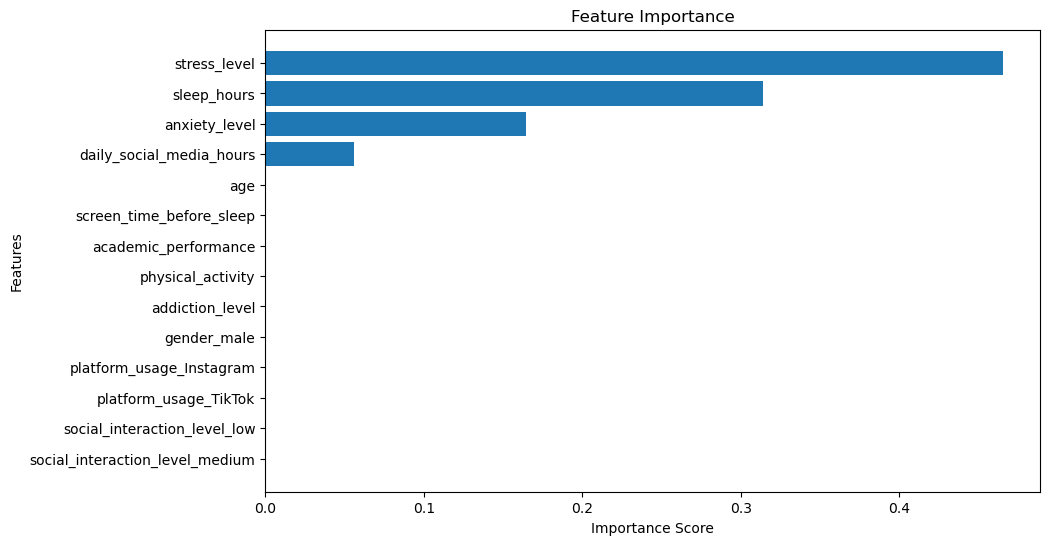

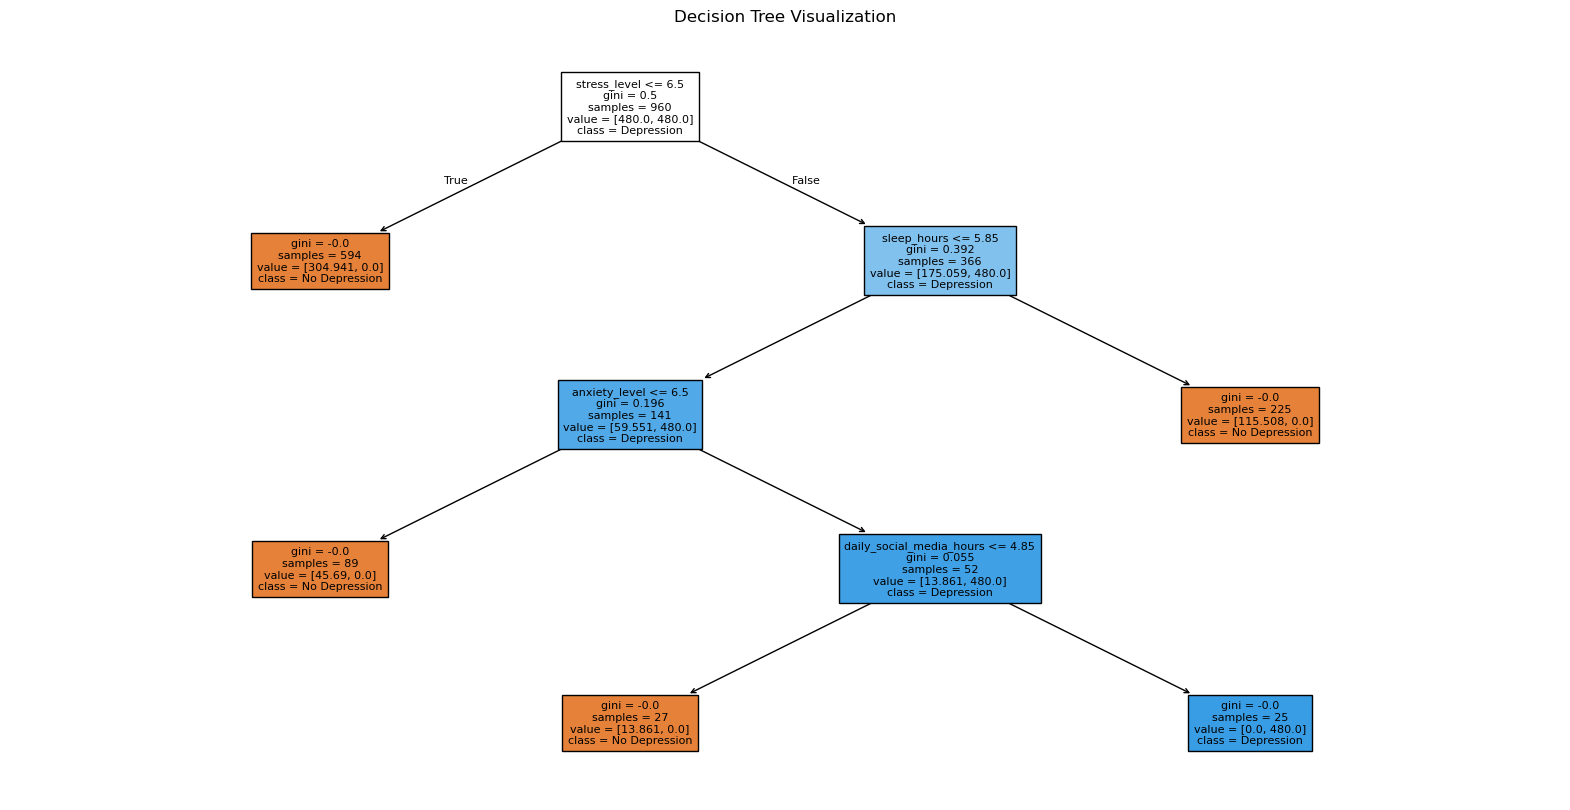

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best Parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best F2 Score:
0.9666666666666666

GRID SEARCH PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
F2 Score : 1.0
ROC AUC  : 1.0


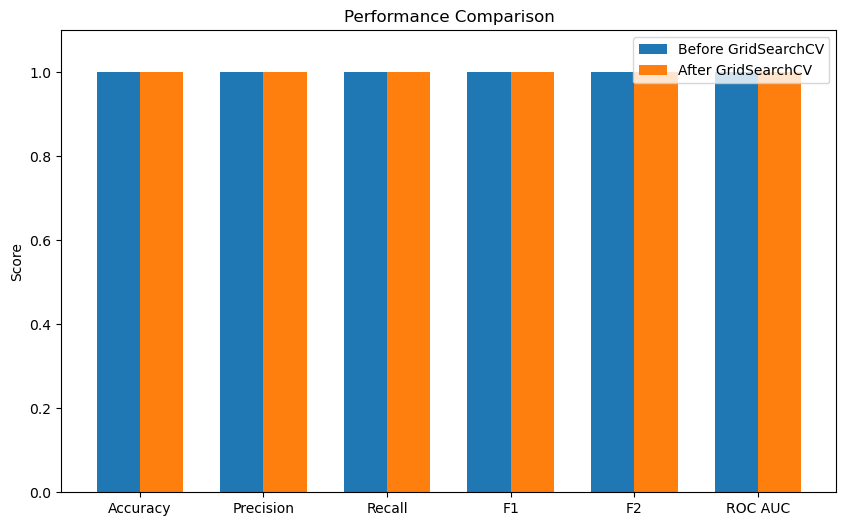

In [2]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    make_scorer
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv(r"D:\college\appliedmaths\Teen_Mental_Health_Dataset.csv")

print(df.head())

# =========================
# DATASET INFORMATION
# =========================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

# =========================
# TARGET VARIABLE ANALYSIS
# =========================

counts = df['depression_label'].value_counts()

plt.figure(figsize=(5,4))
counts.plot(kind='bar')

plt.title("Depression Label Distribution")
plt.xlabel("Depression Label")
plt.ylabel("Count")

plt.show()

print("\nClass Distribution:")
print(counts)

# =========================
# DATA PREPROCESSING
# =========================

X = df.drop(columns=['depression_label'])
y = df['depression_label']

# Convert categorical columns into numeric
X = pd.get_dummies(X, drop_first=True)

print("\nEncoded Features:")
print(X.head())

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================
# DECISION TREE MODEL
# =========================

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5
)

# Train model
dt_model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

y_pred = dt_model.predict(X_test)

# Probabilities for ROC Curve
y_proba = dt_model.predict_proba(X_test)[:,1]

# =========================
# EVALUATION METRICS
# =========================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

f2 = fbeta_score(y_test, y_pred, beta=2)

roc_auc = roc_auc_score(y_test, y_proba)

# =========================
# PRINT SCORES
# =========================

print("\n=========================")
print("MODEL PERFORMANCE")
print("=========================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("F2 Score :", f2)
print("ROC AUC  :", roc_auc)

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Depression', 'Depression'],
    yticklabels=['No Depression', 'Depression']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# =========================
# ROC CURVE
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# =========================
# VISUALIZE DECISION TREE
# =========================

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Depression', 'Depression'],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

# =========================
# GRID SEARCH CV
# =========================

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

f2_scorer = make_scorer(
    fbeta_score,
    beta=2
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Train GridSearchCV
grid.fit(X_train, y_train)

# =========================
# BEST PARAMETERS
# =========================

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest F2 Score:")
print(grid.best_score_)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

best_proba = best_model.predict_proba(X_test)[:,1]

# =========================
# FINAL METRICS
# =========================

best_accuracy = accuracy_score(y_test, best_pred)

best_precision = precision_score(y_test, best_pred)

best_recall = recall_score(y_test, best_pred)

best_f1 = f1_score(y_test, best_pred)

best_f2 = fbeta_score(y_test, best_pred, beta=2)

best_roc_auc = roc_auc_score(y_test, best_proba)

print("\n=========================")
print("GRID SEARCH PERFORMANCE")
print("=========================")

print("Accuracy :", best_accuracy)
print("Precision:", best_precision)
print("Recall   :", best_recall)
print("F1 Score :", best_f1)
print("F2 Score :", best_f2)
print("ROC AUC  :", best_roc_auc)

# =========================
# COMPARISON GRAPH
# =========================

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'F2',
    'ROC AUC'
]

before_scores = [
    accuracy,
    precision,
    recall,
    f1,
    f2,
    roc_auc
]

after_scores = [
    best_accuracy,
    best_precision,
    best_recall,
    best_f1,
    best_f2,
    best_roc_auc
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    before_scores,
    width,
    label='Before GridSearchCV'
)

plt.bar(
    x + width/2,
    after_scores,
    width,
    label='After GridSearchCV'
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("Performance Comparison")

plt.ylim(0,1.1)

plt.legend()

plt.show()